In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

### Helpers

In [2]:
class Noise:
    def __init__(self, mu, sd, n_dist_per_plot, n_samples_per_dist, dist_support_samples):
        self.mu = mu
        self.sd = sd
        self.n_dist_per_plot = n_dist_per_plot
        self.n_samples_per_dist = n_samples_per_dist
        self.dist_support_samples = dist_support_samples
        self.support = np.linspace(-4 * sd, 4 * sd, dist_support_samples)
        self.samples = np.random.normal(mu, sd, (n_plots, n_samples_per_dist, n_dist_per_plot))
        self.dist = stats.norm.pdf(self.support, mu, sd)

In [3]:
def draw_noise_samples_at(ax, noise_samples, xpos, ypos):
    # All the same color, then just:
    #ypos_samples = noise_samples[:, np.newaxis] + ypos
    #ax.plot(np.tile(xpos, noise_samples.shape[0]), ypos_samples.ravel(), 'o', alpha=0.5)
    
    for samples in noise_samples:
        ax.plot(xpos, ypos + samples, 'o', alpha=0.5)


def draw_distributions_at(ax, dist, support, xpos, ypos):    
    dist_all = dist[:, np.newaxis] + xpos
    support_all = support[:, np.newaxis] + ypos
    
    ax.plot(dist_all, support_all, color='k', lw=0.5, alpha=0.7)
    ax.vlines(xpos, ymin=support.min() + ypos, ymax=support.max() + ypos, color='k', lw=0.1)    
    ax.hlines(ypos, xmin=xpos, xmax=dist.max() + xpos, color='k', lw=0.1)    


def get_dist_pos(x, y, n_dist_per_plot):
    delta = len(x) // (n_dist_per_plot + 1)
    idxs = np.arange(delta - 1, len(x) - delta, delta)
    return x[idxs], y[idxs]

### Config

In [4]:
b = (-1 if np.random.rand() < 0.5 else 1) * np.random.randint(1, 4)
w = (-1 if np.random.rand() < 0.5 else 1) * np.random.randint(3, 7)

x = np.linspace(0, 3, 100)
y = w * x + b

noise_config = {
    'mu': 0,
    'sd': 1,
    'n_dist_per_plot': 5,
    'n_samples_per_dist': 1,
    'dist_support_samples': 101,
}

n_plots = 4 if noise_config['n_samples_per_dist'] == 1 else 1

for n_cols in range(5, 1, -1):
    if n_plots % n_cols == 0:
        break
else:
    n_cols = n_plots

n_rows = n_plots // n_cols

### Simulation

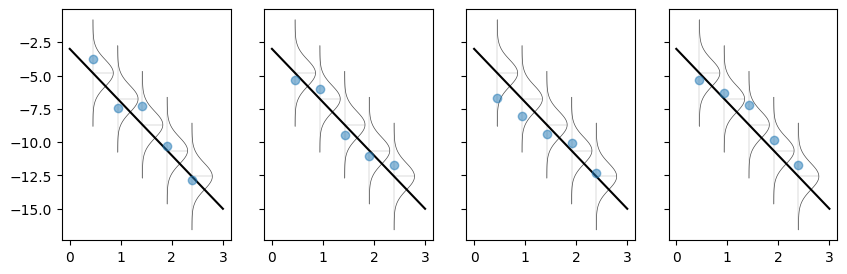

In [5]:
noise = Noise(**noise_config)
xpos, ypos = get_dist_pos(x, y, noise.n_dist_per_plot)

fig, axes = plt.subplots(n_rows, n_cols, sharex='all', sharey='all', figsize=(10, 3 * n_rows))
axes = np.array([axes]) if type(axes) != np.ndarray else axes

for i, (ax, noise_samples) in enumerate(zip(axes.flat, noise.samples)):
    ax.plot(x, y, 'k')
    draw_distributions_at(ax, noise.dist, noise.support, xpos, ypos)
    draw_noise_samples_at(ax, noise_samples, xpos, ypos)

In [6]:
def create_roots(min_x, max_x, pol_order):
    # Equispaced roots plus some randomness to move a little bit the roots at each run
    roots = np.linspace(min_x, max_x, pol_order) + (max_x - min_x) * np.random.randn(pol_order) / (2 * pol_order)
    # Force the first and last root to be in the interval [min_x; max_x]
    roots[0] = max(min_x, roots[0])
    roots[-1] = min(roots[-1], max_x)
    return roots

def complex_func(x_interval, roots):
    # For each x in the support of y
    for idx in range(len(x_interval)):
        # Evaluate (x_idx - r_1)(x_idx - r_2)...(x_idx - r_pol_order)
        x_interval[idx] = np.prod(x_interval[idx] - roots)
    return x_interval

In [7]:
min_x, max_x,  = 0, 3
q_samples, q_steps_interval = 100, 100
pol_order, sigma = 6, 0.1

x_interval = np.linspace(min_x, max_x, q_steps_interval).reshape(-1, 1)
x_samples = min_x + (max_x - min_x) * np.random.rand(q_samples, 1)

# Generate the roots
roots = create_roots(x_interval[0][0], x_interval[-1][0], pol_order)
y_real = complex_func(x_interval.copy(), roots)

# Normalizing the to the interval [0; 1]
factor = np.max(np.abs(y_real))
y_real /= 0.25 

x = x_interval
y = y_real

In [8]:
x.shape, y.shape 

((100, 1), (100, 1))

In [9]:
noise = Noise(**noise_config)
xpos, ypos = get_dist_pos(x, y, noise.n_dist_per_plot)
xpos, ypos = xpos.flatten(), ypos.flatten()

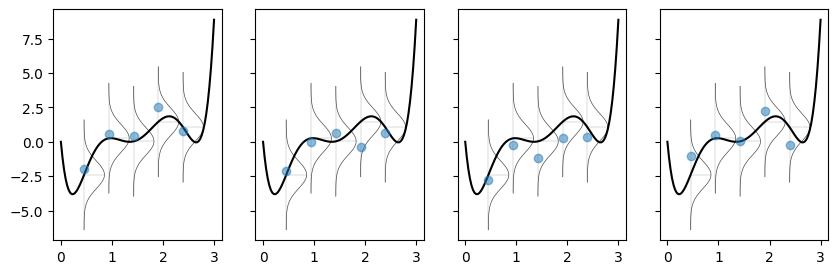

In [10]:
fig, axes = plt.subplots(n_rows, n_cols, sharex='all', sharey='all', figsize=(10, 3 * n_rows))
axes = np.array([axes]) if type(axes) != np.ndarray else axes

for i, (ax, noise_samples) in enumerate(zip(axes.flat, noise.samples)):
    ax.plot(x, y, 'k')
    draw_distributions_at(ax, noise.dist, noise.support, xpos, ypos)
    draw_noise_samples_at(ax, noise_samples, xpos, ypos)